

Problem 1(a)
\begin{equation}
f(\alpha) = |y - \alpha a|_2^2
\end{equation}

\begin{equation}
f(\alpha) = |y|_2^2 - 2\alpha \langle y, a \rangle + \alpha^2 |a|_2^2
\end{equation}

\begin{equation}
\frac{d}{d\alpha}f(\alpha) = -2\langle y, a \rangle + 2\alpha |a|_2^2
\end{equation}

\begin{equation}
0 = -2\langle y, a \rangle + 2\alpha |a|_2^2
\end{equation}

\begin{equation}
\alpha = \frac{\langle y, a \rangle}{|a|_2^2}
\end{equation}

Problem 1(b)
\begin{equation}
\alpha_i = \frac{\langle y, a_i \rangle}{|a_i|_2^2}
\end{equation}

\begin{equation}
r = y - \alpha_i a_i = y - \frac{\langle y, a_i \rangle}{|a_i|_2^2} a_i
\end{equation}

\begin{equation}
|r|_2^2 = |y|_2^2 - \frac{|\langle y, a_i \rangle|^2}{|a_i|_2^2}
\end{equation}

\begin{equation}
\frac{|\langle y, a_i \rangle|}{|a_i|_2}
\end{equation}

Question 1c

The Matching Pursuit (MP) algorithm is designed to iteratively build an approximation of the original signal by selecting the most important features step by step. At each iteration, the algorithm identifies the column of the matrix that best aligns with the current residual — the portion of the signal that remains unexplained. This alignment is determined by maximizing the inner product between the residual and the chosen column, relative to the column's norm. By selecting the feature that contributes the most to reducing the residual error, MP efficiently refines its estimate of the original sparse signal. The algorithm continues this process, gradually improving the signal approximation and ensuring that each selected feature plays a meaningful role in reconstructing the true signal. This stepwise reduction of the residual is what makes MP an effective method for sparse recovery.

Problem 2(a)

\begin{equation}
f(u) = |y - A_I u|_2^2
\end{equation}

\begin{equation}
f(u) = |y|_2^2 - 2y^T A_I u + u^T A_I^T A_I u
\end{equation}

\begin{equation}
\frac{\partial f}{\partial u} = -2A_I^T y + 2 A_I^T A_I u
\end{equation}

\begin{equation}
A_I^T A_I u = A_I^T y
\end{equation}

\begin{equation}
u = (A_I^T A_I)^{-1} A_I^T y
\end{equation}



Question 2d

When Orthogonal Matching Pursuit (OMP) is run for more steps than the true sparsity level, meaning , the algorithm is likely to include unnecessary features that do not contribute meaningfully to the signal reconstruction. This situation is known as overfitting. Although the reconstructed signal may still achieve a low mean squared error (MSE), the false alarm rate may increase because the algorithm is adding non-relevant features. As a result, the reconstructed signal may lose interpretability by including too much noise or irrelevant details.

On the other hand, if OMP is run for fewer steps than the true sparsity level, meaning , the algorithm will stop early before identifying all the necessary features. This leads to an increase in the miss detection rate, as some true non-zero entries will be excluded from the final estimate. Consequently, the reconstructed signal may show a higher MSE and fail to capture the full structure of the original signal.

Since the true value of  is rarely known in practice, adaptive techniques such as cross-validation or residual-based stopping criteria are often used to estimate the appropriate stopping point. These methods help balance the risk of overfitting and underfitting, improving the overall performance of the algorithm.



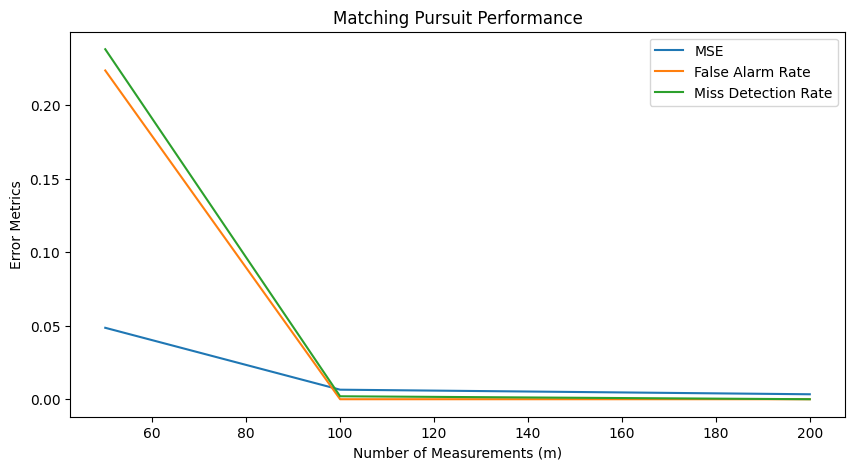

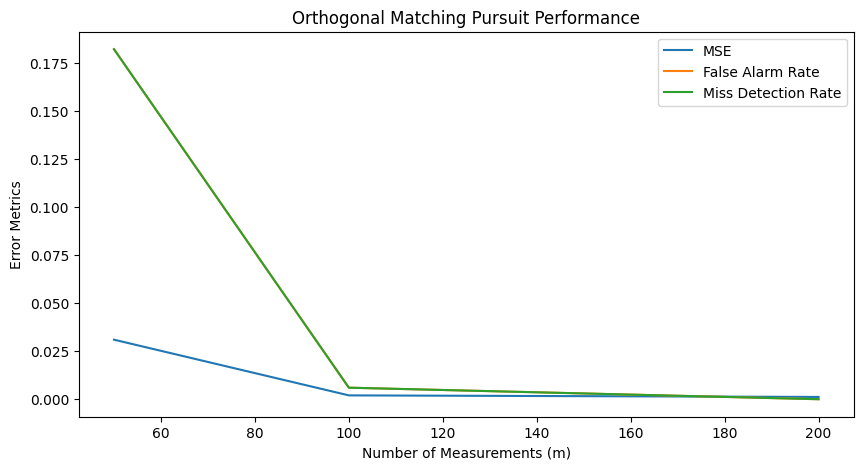

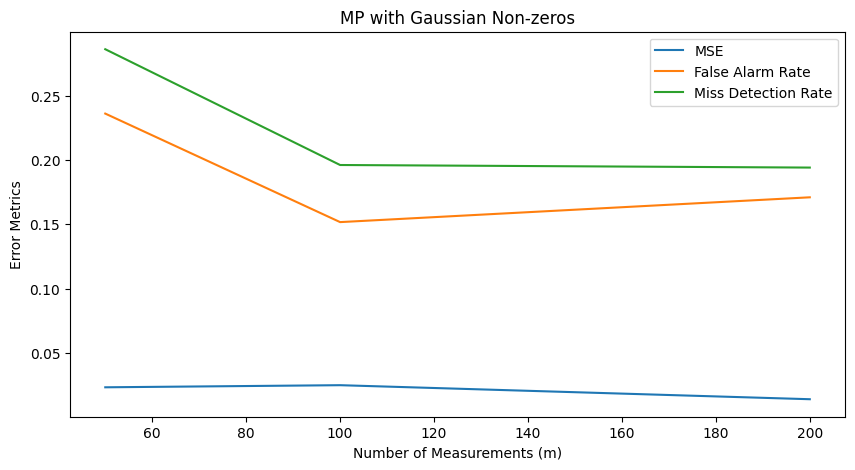

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def generate_sparse_signal(n=100, k=10, gaussian_values=False):
    x = np.zeros(n)
    indices = np.random.choice(n, k, replace=False)
    if gaussian_values:
        x[indices] = np.random.randn(k) 
    else:
        x[indices] = 1 
    return x

def generate_measurements(x, m=50, sigma_z=0.01):
    n = len(x)
    A = np.random.randn(m, n) / np.sqrt(m)
    z = np.random.randn(m) * np.sqrt(sigma_z)
    y = A @ x + z
    return A, y, z

def matching_pursuit(A, y, k):
    m, n = A.shape
    x_hat = np.zeros(n)
    r = y.copy()
    I = set()
    
    for _ in range(k):
        i_t = np.argmax(np.abs(A.T @ r) / np.linalg.norm(A, axis=0))
        I.add(i_t)
        x_hat[i_t] = np.dot(A[:, i_t], r) / np.linalg.norm(A[:, i_t])**2
        r -= x_hat[i_t] * A[:, i_t]
    
    return x_hat

def orthogonal_matching_pursuit(A, y, k):
    m, n = A.shape
    x_hat = np.zeros(n)
    r = y.copy()
    I = []
    
    for _ in range(k):
        i_t = np.argmax(np.abs(A.T @ r) / np.linalg.norm(A, axis=0))
        I.append(i_t)
        A_I = A[:, I]  # Submatrix with selected columns
        x_I = np.linalg.pinv(A_I) @ y
        r = y - A_I @ x_I
    
    x_hat[I] = x_I
    return x_hat

def evaluate_performance(x, x_hat):
    mse = np.mean((x - x_hat) ** 2)
    false_alarms = np.sum((x_hat != 0) & (x == 0)) / max(1, np.sum(x_hat != 0))
    miss_detection = np.sum((x_hat == 0) & (x != 0)) / max(1, np.sum(x != 0))
    return mse, false_alarms, miss_detection

m_values = [50, 100, 200]
k = 10
n_trials = 50

def run_experiment(algorithm, gaussian_values=False):
    mse_list, false_alarm_list, miss_detection_list = [], [], []
    for m in m_values:
        mse_trials, false_alarm_trials, miss_detection_trials = [], [], []
        for _ in range(n_trials):
            x = generate_sparse_signal(n=100, k=k, gaussian_values=gaussian_values)
            A, y, _ = generate_measurements(x, m=m)
            x_hat = algorithm(A, y, k)
            mse, fa, md = evaluate_performance(x, x_hat)
            mse_trials.append(mse)
            false_alarm_trials.append(fa)
            miss_detection_trials.append(md)
        mse_list.append(np.mean(mse_trials))
        false_alarm_list.append(np.mean(false_alarm_trials))
        miss_detection_list.append(np.mean(miss_detection_trials))
    
    return mse_list, false_alarm_list, miss_detection_list

def plot_results(m_values, mse_list, false_alarm_list, miss_detection_list, title):
    plt.figure(figsize=(10, 5))
    plt.plot(m_values, mse_list, label='MSE')
    plt.plot(m_values, false_alarm_list, label='False Alarm Rate')
    plt.plot(m_values, miss_detection_list, label='Miss Detection Rate')
    plt.xlabel('Number of Measurements (m)')
    plt.ylabel('Error Metrics')
    plt.legend()
    plt.title(title)
    plt.show()

mse_mp, fa_mp, md_mp = run_experiment(matching_pursuit)
mse_omp, fa_omp, md_omp = run_experiment(orthogonal_matching_pursuit)
mse_mp_gauss, fa_mp_gauss, md_mp_gauss = run_experiment(matching_pursuit, gaussian_values=True)

plot_results(m_values, mse_mp, fa_mp, md_mp, 'Matching Pursuit Performance')
plot_results(m_values, mse_omp, fa_omp, md_omp, 'Orthogonal Matching Pursuit Performance')
plot_results(m_values, mse_mp_gauss, fa_mp_gauss, md_mp_gauss, 'MP with Gaussian Non-zeros')